# Generate the Figures

We are going to show an optimization curve figure 

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle

# define the load function to get the initial parameters
def load_history(filename):
    with open(filename, "rb") as f:
        file = pickle.load(f)
    return file

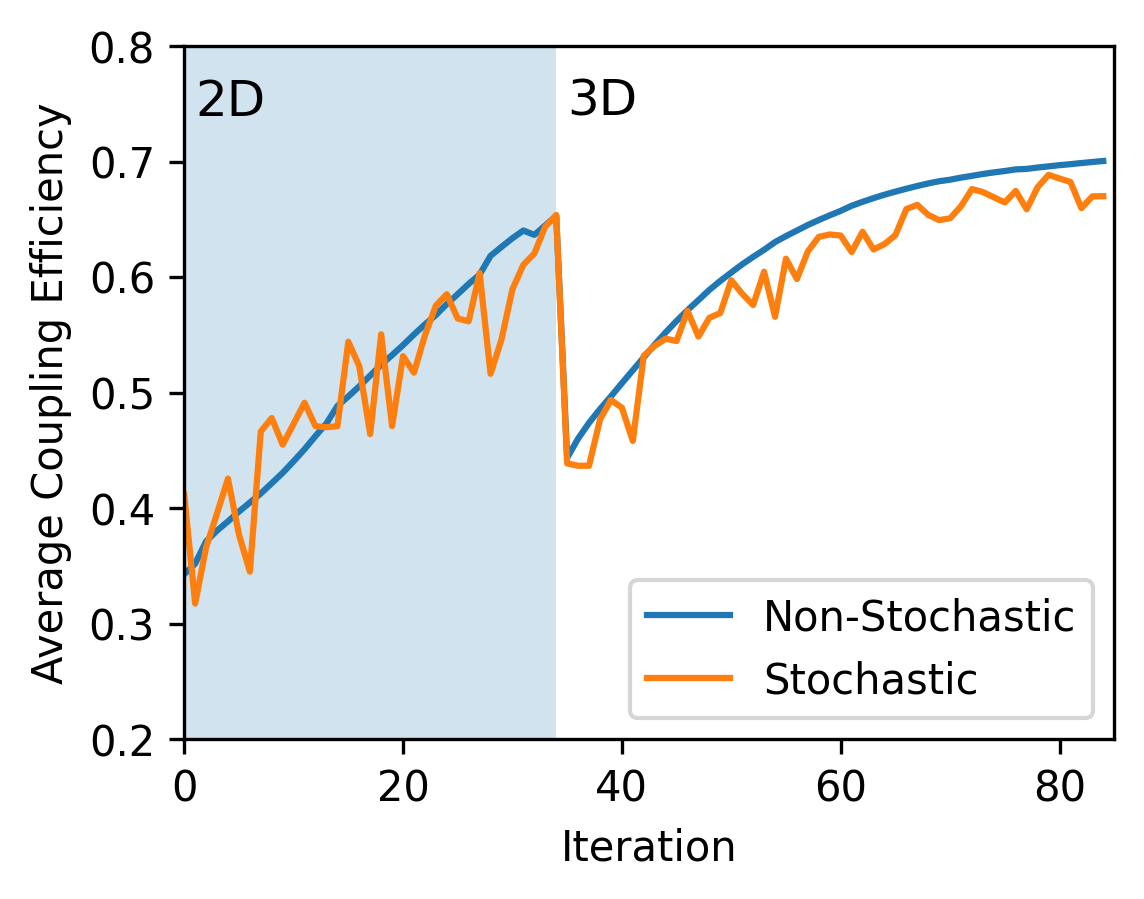

In [28]:
# Load all the history files
history_2D = load_history("../GC_4um_2D/data/opt/history.pkl")['history']
history_2D_stochastic = load_history("../GC_4um_2D/data/opt/history_stochastic.pkl")['history']
history_3D = load_history("../GC_4um_3D/data/3d_opt/history.pkl")['history']
history_3D_stochastic = load_history("../GC_4um_3D/data/3d_opt/history_stochastic.pkl")['history']

# combine the histories into the non-stochastic and stochastic histories
opt_curve = np.concatenate([history_2D['J'], history_3D['J']])
opt_curve_stochastic = np.concatenate([history_2D_stochastic['J'], history_3D_stochastic['J']])

# Plot the optimization curves
fig,ax = plt.subplots(1,1,figsize=(4,3),dpi=300)
plt.plot(opt_curve,label="Non-Stochastic")
plt.plot(opt_curve_stochastic,label="Stochastic")
plt.fill_between(range(35),1,0,alpha=0.2)
plt.xlabel("Iteration")
plt.ylabel("Average Coupling Efficiency")
plt.xlim(0,85)
plt.ylim(0.2,.8)
plt.text(0.05,0.92,"2D",ha="center",va="center",transform=ax.transAxes,fontsize=12)
plt.text(0.45,0.92,"3D",ha="center",va="center",transform=ax.transAxes,fontsize=12)
plt.legend()
plt.show()






